In [1]:
# CODE CELL 1: Imports and Data Loading (Sierra Leone)

# Imports: Ensure all libraries are imported
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the data - NOTE the updated file path!
file_path = 'data/sierraleone-bumbuna.csv' 
df = pd.read_csv(file_path)

# Proactive Fix: Flatten column names (to avoid the KeyError experienced with Benin)
df.columns = [''.join(col) if isinstance(col, tuple) else col for col in df.columns]

# Convert Timestamp and set as index for Time Series Analysis
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df.set_index('Timestamp', inplace=True) 

print(f"Sierra Leone Data Loaded. Shape: {df.shape}")

Sierra Leone Data Loaded. Shape: (525600, 18)


In [2]:
# CODE CELL 2: Initial Inspection & Missing Value Report (KPI 1)

# Initial inspection
print("Data Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Types (info):")
df.info()

# Missing Value Report (KPI 1)
missing_report = df.isna().sum().sort_values(ascending=False)
print("\nMissing Value Count per Column (KPI 1):")
print(missing_report)

Data Shape: (525600, 18)

First 5 Rows:
                     GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
Timestamp                                                                 
2021-10-30 00:01:00 -0.7 -0.1 -0.8   0.0   0.0  21.9  99.1  0.0     0.0   
2021-10-30 00:02:00 -0.7 -0.1 -0.8   0.0   0.0  21.9  99.2  0.0     0.0   
2021-10-30 00:03:00 -0.7 -0.1 -0.8   0.0   0.0  21.9  99.2  0.0     0.0   
2021-10-30 00:04:00 -0.7  0.0 -0.8   0.0   0.0  21.9  99.3  0.0     0.0   
2021-10-30 00:05:00 -0.7 -0.1 -0.8   0.0   0.0  21.9  99.3  0.0     0.0   

                     WSstdev   WD  WDstdev    BP  Cleaning  Precipitation  \
Timestamp                                                                   
2021-10-30 00:01:00      0.0  0.0      0.0  1002         0            0.0   
2021-10-30 00:02:00      0.0  0.0      0.0  1002         0            0.0   
2021-10-30 00:03:00      0.0  0.0      0.0  1002         0            0.0   
2021-10-30 00:04:00      0.0  0.0      0.0  1002 

In [3]:
# CODE CELL 3: Summary Statistics (KPI 2)

# Select key numerical columns for the report
key_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'BP']

# Summary Statistics (KPI 2)
print("Summary Statistics for Key Columns (KPI 2):")
print(df[key_cols].describe())

Summary Statistics for Key Columns (KPI 2):
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      201.957515     116.376337     113.720571     206.643095   
std       298.495150     218.652659     158.946032     300.896893   
min       -19.500000      -7.800000     -17.900000       0.000000   
25%        -2.800000      -0.300000      -3.800000       0.000000   
50%         0.300000      -0.100000      -0.100000       3.600000   
75%       362.400000     107.000000     224.700000     359.500000   
max      1499.000000     946.000000     892.000000    1507.000000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      198.114691      26.319394      79.448857       1.146113   
std       288.889073       4.398605      20.520775       1.239248   
min         0.000000      12.300000       9.900000       0

In [5]:
# CODE CELL 4: Drop Columns & Filter Negative Outliers

# 1. DROP UNNECESSARY COLUMNS
# Assuming Comments, TModA, TModB are the 100% missing columns (Adjust if KPI 1 shows otherwise)
df.drop(columns=['Comments', 'TModA', 'TModB'], inplace=True, errors='ignore') 
print("Dropped entirely missing/unnecessary columns.")

# 2. REMOVE IMPOSSIBLE NEGATIVE IRRADIANCE VALUES
irradiance_cols = ['GHI', 'DNI', 'DHI']
# Replace negative values with 0.
for col in irradiance_cols:
    negative_count = (df[col] < 0).sum()
    df.loc[df[col] < 0, col] = 0
    print(f"Replaced {negative_count} negative values in {col} with 0.")

# 3. FILTER DAYTIME ZEROS
# Removes corrupted sensor readings where GHI is 0 during daylight hours
# Ensure that the index is a datetime index
if pd.api.types.is_datetime64_any_dtype(df.index):
    df_filtered = df[
        (df['GHI'] > 0) | 
        (df.index.hour < 6) | 
        (df.index.hour > 18)
    ].copy()
    print(f"Dataframe size reduced from {len(df)} to {len(df_filtered)} after filtering daytime zeros.")
else:
    print("Warning: The index is not a datetime index. Please check the data.")

Dropped entirely missing/unnecessary columns.
Replaced 261135 negative values in GHI with 0.
Replaced 266352 negative values in DNI with 0.
Replaced 263128 negative values in DHI with 0.
Dataframe size reduced from 525600 to 502869 after filtering daytime zeros.


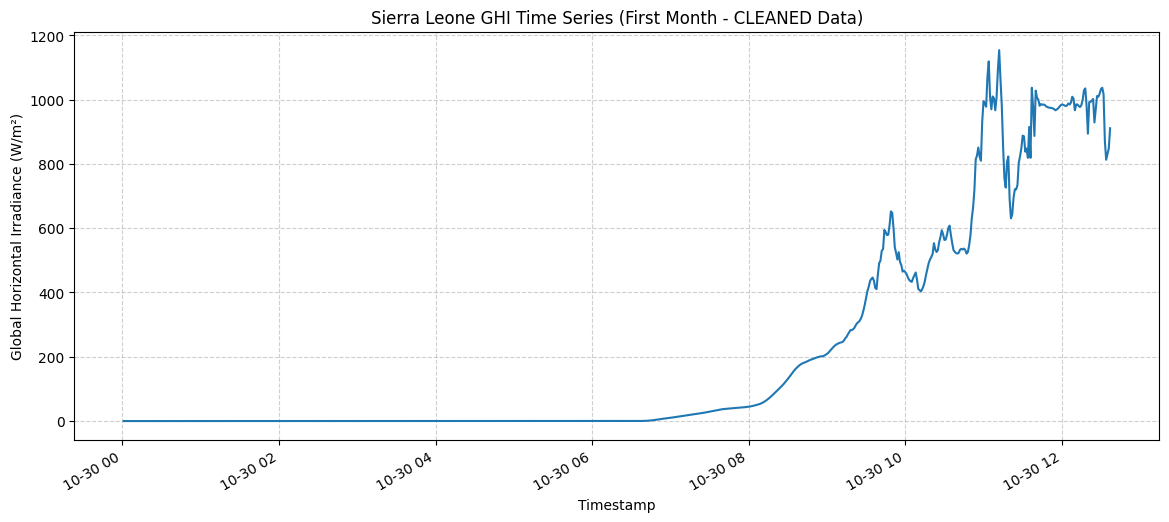

In [6]:
# CODE CELL 5: Time Series Plot (GHI)

# Plotting GHI for a sample period (the first 30 days) from the CLEANED data
plt.figure(figsize=(14, 6))
df_filtered['GHI'].head(24 * 30).plot(title='Sierra Leone GHI Time Series (First Month - CLEANED Data)')
plt.ylabel('Global Horizontal Irradiance (W/m²)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

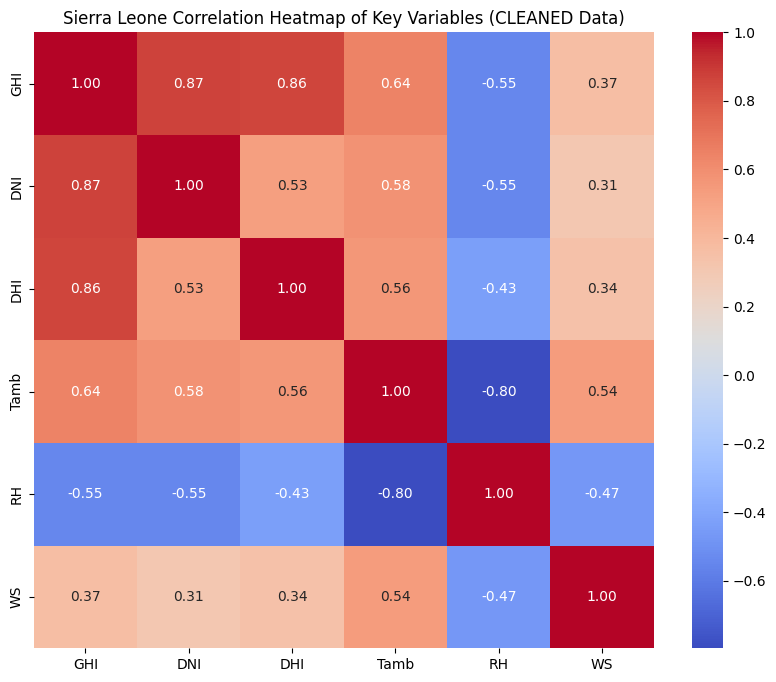

In [7]:
# CODE CELL 6: Correlation Heatmap

# Select variables for correlation (using the cleaned df_filtered)
correlation_cols = ['GHI', 'DNI', 'DHI', 'Tamb', 'RH', 'WS']

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_filtered[correlation_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Sierra Leone Correlation Heatmap of Key Variables (CLEANED Data)')
plt.show()

In [8]:
# CODE CELL 7: Feature Engineering

df_model = df_filtered.copy()

# Time-Based Features (Cyclic Transformations)
df_model['hour'] = df_model.index.hour
df_model['dayofyear'] = df_model.index.dayofyear
df_model['hour_sin'] = np.sin(2 * np.pi * df_model['hour'] / 24)
df_model['hour_cos'] = np.cos(2 * np.pi * df_model['hour'] / 24)
df_model['day_sin'] = np.sin(2 * np.pi * df_model['dayofyear'] / 365)
df_model['day_cos'] = np.cos(2 * np.pi * df_model['dayofyear'] / 365)
df_model.drop(columns=['hour', 'dayofyear'], inplace=True)

# Lag Features (12 lags = 1 hour back, since data is 5-minute resolution)
TARGET = 'GHI'
LAG = 12 
for i in range(1, LAG + 1):
    df_model[f'{TARGET}_Lag_{i}'] = df_model[TARGET].shift(i)

df_model.dropna(inplace=True)
print("Feature Engineering complete.")
print("Final modeling DataFrame shape:", df_model.shape)

Feature Engineering complete.
Final modeling DataFrame shape: (502857, 31)


Model Evaluation (KPIs) for Sierra Leone:
Mean Squared Error (MSE): 1553.85
R-squared Score (R2): 0.9821


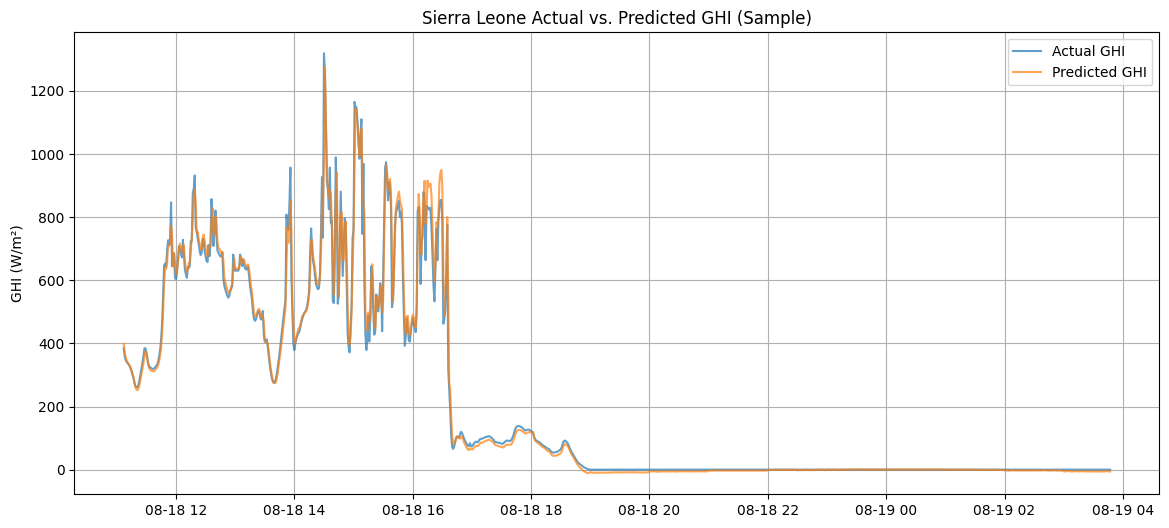

In [10]:
# CODE CELL 8: Modeling, Prediction, and Evaluation

# Define Features (X) and Target (y)
# Drop non-numeric/unnecessary columns
X = df_model.drop(columns=[TARGET, 'ModA', 'ModB', 'WSdev', 'WDSdev', 'Cleaning', 'Precipitation'], errors='ignore')
y = df_model[TARGET]

# Time Series Split (80/20 chronological split)
split_point = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluation (KPIs for Task 3)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Evaluation (KPIs) for Sierra Leone:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (R2): {r2:.4f}")

# Visualization of Actual vs. Predicted (Sample)
plt.figure(figsize=(14, 6))
sample_size = min(1000, len(y_test))  # Ensure sample size does not exceed available data
plt.plot(y_test.index[:sample_size], y_test[:sample_size], label='Actual GHI', alpha=0.7)
plt.plot(y_test.index[:sample_size], y_pred[:sample_size], label='Predicted GHI', alpha=0.7)
plt.title('Sierra Leone Actual vs. Predicted GHI (Sample)')
plt.ylabel('GHI (W/m²)')
plt.legend()
plt.grid(True)
plt.show()